# Preventing Credit Card Defaults - Part 2

In this activity, you will continue working on the neural network model to prevent credit card defaults. In this second part, you will compile, fit, and evaluate the model.

## Instructions:

1. Open the notebook, and run all the cells in the Jupyter notebook that correspond to “Preventing Credit Card Defaults Part 1”.

2. Compile the neural network model using the `binary_crossentropy` loss function, the `adam` optimizer, and the additional metric `accuracy`.

3. Fit the model with the training data, using 100 epochs.

4. Plot the model’s loss function and accuracy over the 100 epochs.

5. Evaluate the model using testing data and the `evaluate` method.


## References:

[Keras Sequential model](https://keras.io/api/models/sequential/)

[Keras Dense module](https://keras.io/api/layers/core_layers/dense/)

[Keras evaluate](https://keras.io/api/models/model_training_apis/)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

## Step 1: Run all the cells in the Jupyter notebook that correspond to “Preventing Credit Card Defaults Part 1”.

In [6]:
cc_df = pd.read_csv(
    Path("13.1/01_Preventing_Credit_Card_Defaults_Part_1/Resources/cc_default.csv")
)

# Review the DataFrame
cc_df.head()

,LIMIT_BAL,EDUCATION,MARITAL_STATUS,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,"""BILL_AMT4""",BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,1,24,2,2,-1,-1,-2,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,26,-1,2,0,0,0,2,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,34,0,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,1,37,0,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,2,1,57,-1,0,-1,0,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Define the features set `X` by including all of the DataFrame columns except the “DEFAULT” column.

In [7]:
# Define features set X by selecting all columns but DEFAULT
X = cc_df.drop(columns=['DEFAULT']).copy()
X.head()

,LIMIT_BAL,EDUCATION,MARITAL_STATUS,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,BILL_AMT3,"""BILL_AMT4""",BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,1,24,2,2,-1,-1,-2,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,26,-1,2,0,0,0,2,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,34,0,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,1,37,0,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,2,1,57,-1,0,-1,0,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


### Create the target `y` by assigning the values of the DataFrame “DEFAULT” column.

In [8]:
# Define target set by selecting the DEFAULT column
y = cc_df['DEFAULT']
y[:5]

0    1
1    1
2    0
3    0
4    0
Name: DEFAULT, dtype: int64

### Create the training and testing sets using the `train_test_split` function from scikit-learn.

In [9]:
# Create training and testing datasets using train_test_split
# Assign the function a random_state equal to 1
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=1)

### Scale the features data using the `StandardScaler` from sklearn.

In [10]:
# Create the StandardScaler instance
X_scaler = StandardScaler()

In [11]:
X_scaler.fit(X_train)

StandardScaler()

In [12]:
# Scale both the training and testing data from the features dataset
X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

### Create a neural network model with an input layer that consists of 22 inputs, one hidden layer, and an output layer. Use the `units` parameter to define 12 neurons for the hidden layer and a single output for the output layer. Use the ReLU activation function for the hidden layer and the sigmoid activation function for the output layer.

In [13]:
# Define the the number of inputs to the model
number_inputs = 22

# Define the number of hidden nodes for the model
number_hidden_nodes = 12

# Create the Sequential model instance
neuron = Sequential()

# Add a Dense layer specifying the number of inputs, the number of hidden nodes, and the activation function
neuron.add(Dense(units=number_hidden_nodes, input_dim=number_inputs, activation='relu'))

# Add the output layer to the model specifying the number of output neurons and activation function
neuron.add(Dense(1,activation='sigmoid'))

### Display the model structure using the `summary` function.

In [14]:
# Display the Sequential model summary
neuron.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 12)                276       
                                                                 
 dense_1 (Dense)             (None, 1)                 13        
                                                                 
Total params: 289
Trainable params: 289
Non-trainable params: 0
_________________________________________________________________


## Step 2:  Compile the neural network model using the `binary_crossentropy` loss function, the `adam` optimizer, and the additional metric `accuracy`.

In [16]:
# Compile the Sequential model
neuron.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

## Step 3: Fit the model with 100 epochs using the training data.

In [17]:
# Fit the model using 100 epochs and the training data
model=neuron.fit(X_train_scaled,y_train,epochs=100)

Epoch 1/100


2026-05-13 16:31:17.635103: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


704/704 [==============================] - 0s 364us/step - loss: 0.5606 - accuracy: 0.7400
Epoch 2/100
704/704 [==============================] - 0s 349us/step - loss: 0.4704 - accuracy: 0.8082
Epoch 3/100
704/704 [==============================] - 0s 345us/step - loss: 0.4543 - accuracy: 0.8134
Epoch 4/100
704/704 [==============================] - 0s 350us/step - loss: 0.4471 - accuracy: 0.8165
Epoch 5/100
704/704 [==============================] - 0s 347us/step - loss: 0.4432 - accuracy: 0.8182
Epoch 6/100
704/704 [==============================] - 0s 347us/step - loss: 0.4407 - accuracy: 0.8193
Epoch 7/100
704/704 [==============================] - 0s 351us/step - loss: 0.4385 - accuracy: 0.8200
Epoch 8/100
704/704 [==============================] - 0s 347us/step - loss: 0.4370 - accuracy: 0.8207
Epoch 9/100
704/704 [==============================] - 0s 348us/step - loss: 0.4359 - accuracy: 0.8207
Epoch 10/100
704/704 [==============================] - 0s 346us/step - loss: 0.4341 

Epoch 80/100
704/704 [==============================] - 0s 347us/step - loss: 0.4239 - accuracy: 0.8226
Epoch 81/100
704/704 [==============================] - 0s 348us/step - loss: 0.4238 - accuracy: 0.8223
Epoch 82/100
704/704 [==============================] - 0s 354us/step - loss: 0.4239 - accuracy: 0.8228
Epoch 83/100
704/704 [==============================] - 0s 347us/step - loss: 0.4241 - accuracy: 0.8226
Epoch 84/100
704/704 [==============================] - 0s 348us/step - loss: 0.4238 - accuracy: 0.8224
Epoch 85/100
704/704 [==============================] - 0s 346us/step - loss: 0.4237 - accuracy: 0.8227
Epoch 86/100
704/704 [==============================] - 0s 348us/step - loss: 0.4238 - accuracy: 0.8229
Epoch 87/100
704/704 [==============================] - 0s 346us/step - loss: 0.4236 - accuracy: 0.8228
Epoch 88/100
704/704 [==============================] - 0s 349us/step - loss: 0.4237 - accuracy: 0.8229
Epoch 89/100
704/704 [==============================] - 0s 348us

## Step 4: Plot the model’s loss function and accuracy over the 100 epochs.

In [19]:
# Create a DataFrame using the model history and an index parameter
model_plot = pd.DataFrame(model.history,index=range(1,len(model.history['loss'])+1))
model_plot.head()

,loss,accuracy
1,0.560635,0.739956
2,0.470419,0.808222
3,0.454277,0.813422
4,0.447120,0.816489
5,0.443189,0.818178


/opt/miniconda3/envs/tensor/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<AxesSubplot:>

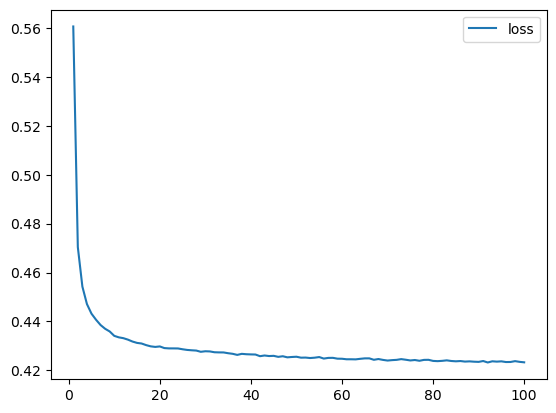

In [20]:
# Vizualize the model plot where the y-axis displays the loss metric
model_plot.plot(y='loss')

<AxesSubplot:>

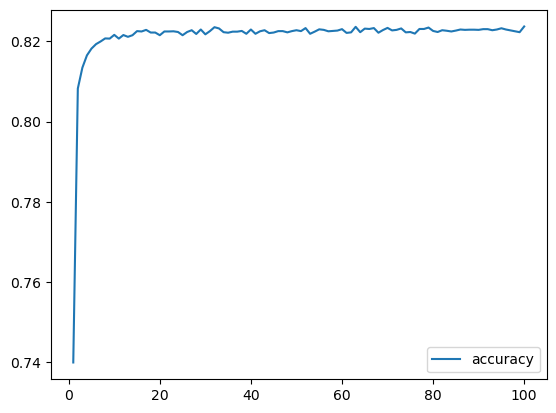

In [21]:
# Vizualize the model plot where the y-axis displays the accuracy metric
model_plot.plot(y='accuracy')

## Step 5: Evaluate the model using testing data and the `evaluate` method.

In [22]:
# Evaluate the model loss and accuracy metrics using the evaluate method and the test data
model_loss, model_accuracy = neuron.evaluate(X_test_scaled, y_test, verbose=2)

# Display the evaluation results
print(f"Loss: {model_loss}, Accuracy: {model_accuracy}")

235/235 - 0s - loss: 0.4359 - accuracy: 0.8173 - 128ms/epoch - 545us/step
Loss: 0.435946524143219, Accuracy: 0.8173333406448364
